# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Evita Meilinda Yudhit Nabena
- **Email:** evitameilinda03@gmail.com
- **ID Dicoding:** evitamyna

## Menentukan Pertanyaan Bisnis

- Bagaimana tren bulanan polutan PM2.5 di setiap stasiun?
- Polutan udara mana yang memiliki konsentrasi tertinggi saat rush hour?
- Faktor cuaca apa yang paling berpengaruh terhadap masing-masing polutan udara?

## Import Semua Packages/Library yang Digunakan

In [1]:
import gdown
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import folium

## Data Wrangling

### Gathering Data
**Persiapan dan Penggabungan Data**

Membaca dan menggabungkan file air quality dataset dari 12 stasiun di Beijing. Gabungan data disimpan sebagai air_quality_combined.csv

In [2]:
url = 'https://drive.google.com/drive/folders/1T5aaO-Hj_g9YyzP5yZOyTWwF-zbawjpm?usp=sharing'

In [3]:
d1 = pd.read_csv('https://drive.google.com/uc?export=download&id=1TJKOd9n0zdtDM0M6nN6IrL84pI_MiT98')
d2 = pd.read_csv('https://drive.google.com/uc?export=download&id=1iNbtNRNQoswVFL7YMdhvppQXY5-u8E0M')
d3 = pd.read_csv('https://drive.google.com/uc?export=download&id=1U8xihUlzsG9dDJqJMXl9poTfVMn3ARYB')
d4 = pd.read_csv('https://drive.google.com/uc?export=download&id=1V6-_on6CD77z2xSt0rNRW3GA9DMzJpUi')
d5 = pd.read_csv('https://drive.google.com/uc?export=download&id=1-iNrJcTADn8gET7Tik4yhbZuI3EDuesr')
d6 = pd.read_csv('https://drive.google.com/uc?export=download&id=1RkF8cUzbEOCTe2I-60fEu2Eg2WX5fovj')
d7 = pd.read_csv('https://drive.google.com/uc?export=download&id=1PymfqR2qne0qBWKMJmGbsFof8tQIcScr')
d8 = pd.read_csv('https://drive.google.com/uc?export=download&id=1TGL8oVM3dh-9Iqu1TQjkUvB6SsP6wG3l')
d9 = pd.read_csv('https://drive.google.com/uc?export=download&id=18Is9UmwDnt6OwS0d1r1lfye_DWILkg1b')
d10 = pd.read_csv('https://drive.google.com/uc?export=download&id=16pF6_MgVK-a7XaKJ9k9CnOt4gOD2rK7G')
d11 = pd.read_csv('https://drive.google.com/uc?export=download&id=1aHQdK0xtKpUUyoq8oSoNrP3djDqwx2xz')
d12 = pd.read_csv('https://drive.google.com/uc?export=download&id=1zRbdysfyBg_F8BvgNIUVFXQtPQeCTaOW')

df = pd.concat([d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12], ignore_index=True)
combined_file = '/content/air_quality_combined.csv'
df.to_csv(combined_file, index=False)

In [4]:
df = pd.read_csv('/content/air_quality_combined.csv')
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Dataset merupakan gabungan dari **12 stasiun di Beijing**, yaitu stasiun Aotizhongxin, Changping, Dingling, Dongsi, Guanyuan, Gucheng, Huairou, Nongzhanguan, Shunyi, Tiantan, Wanliu, Wanshouxigong.
- Periode pengambilan data adalah **4 tahun**, mulai 2013 hingga 2017.
- Kolom tahun, bulan, hari, dan jam mempresentasikan waktu dari setiap observasi.
- **Polutan**: PM 2.5, PM10,SO2, NO2, CO, dan O3.
- **Faktor Cuaca**: TEMP (Temperatur), PRES (Tekanan Udara), DEWP (Dew Point), RAIN (Curah Hujan), wd (Arah Angin), WSPM (Kecepatan Angin).


### Assessing Data


**Membuat Kolom Datetime**

Membuat kolom di dataset yang berisi tanggal dan waktu daalam format, YYYY-MM-DD-HH:00:00.

In [5]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']],
                                errors='coerce',
                                format='%Y-%m-%d %H')
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


**Memahami Struktur Data**

Mengetahui informasi dataset berupa nama kolom, jumlah data non-null, dan tipe data.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  object        
 16  WSPM      420450 non-null  float64    

**Statistik Deskriptif**

In [7]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000,420768
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711,2015-03-01 11:30:00.000001024
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000,2015-03-01 11:30:00
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386,NaN


**Missing Values**

In [8]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


**Data Duplikat**

In [9]:
df.duplicated().sum()

np.int64(0)

**Pemeriksaan Inconsistent**

In [10]:
obj = df.select_dtypes(include=['object']).columns
inconsistent = {}

for col in obj:
    inconsistent[col] = df[col].unique()

inconsistent

{'wd': array(['NNW', 'N', 'NW', 'NNE', 'ENE', 'E', 'NE', 'W', 'SSW', 'WSW', 'SE',
        'WNW', 'SSE', 'ESE', 'S', 'SW', nan], dtype=object),
 'station': array(['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan',
        'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan',
        'Wanliu', 'Wanshouxigong'], dtype=object)}

**Outlier**

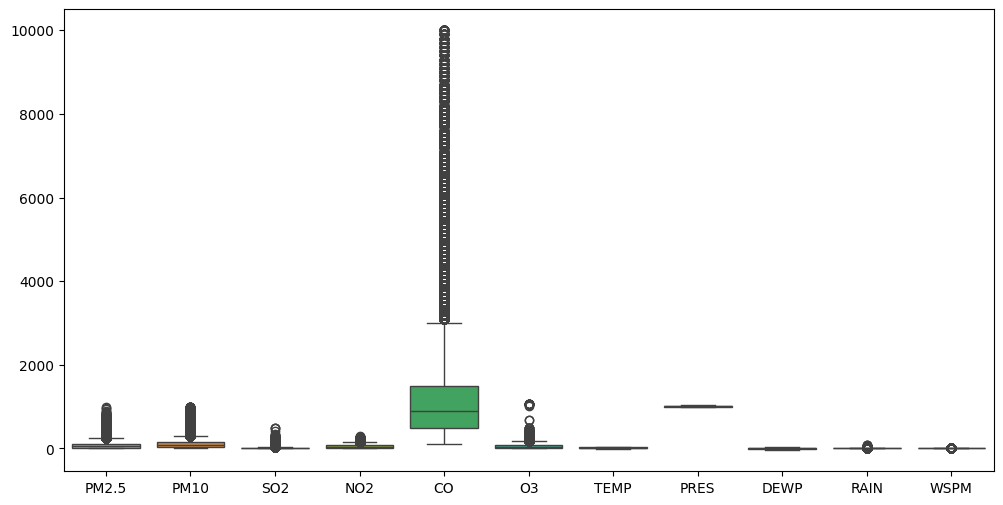

In [11]:
numerik = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerik])
plt.show()

**Insight:**
- Dataset memiliki 420.768 baris dan 19 kolom.
- Statistik deskriptif menunjukan kondisi udara yang cenderung ekstrem, mengindikasikan adanya otulier. Nilai maksimal pada beberapa polutan mencapai angka yang tidak wajar
  - PM2.5 & PM10 : 999 µg/m³
  - CO : 10.000 µg/m³
  - O3 : 1.071 µg/m³
- Terdapat **missing values pada polutan**
  - PM2.5 : 8.739 baris
  - PM10 : 6.449 baris
  - SO2 : 9.021 baris
  - NO2 : 12.116 baris
  - CO : 20.701 baris
  - O3 : 13.277 baris
- Terdapat **missing values minor pada variabel cuaca**
  - TEMP : 398 baris
  - PRES : 393 baris
  - DEWP : 403 baris
  - RAIN : 390 baris
  - wd : 1.822 baris
  - WSPM : 318 baris
- **Tidak terdapat duplicate data** pada setiap kolom.
- **Distribusi waktu data**:
  - Rentang waktu dari 1 Maret 2013 hingga 28 Februari 2017
  - Terdiri dari tahun, bulan, hari, dan jam
- Terdapat **inconsistent value** antara WSPM dan wd, di mana wd memiliki jumlah missing values yang lebih besar dibandingkan WSPM.


### Cleaning Data

**Menangani Missing Values**

In [12]:
df.isnull().sum() / len(df) * 100

,0
No,0.000000
year,0.000000
month,0.000000
day,0.000000
hour,0.000000
PM2.5,2.076916
PM10,1.532674
SO2,2.143937
NO2,2.879497
CO,4.919813


In [13]:
numerik = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']
df[numerik] = df[numerik].interpolate(method='linear')

In [14]:
df['RAIN'] = df['RAIN'].fillna(0)
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

In [15]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


**Menangani Outlier**

In [16]:
for col in numerik:

    # Menghitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Menghitung Interquartile Range (IQR)
    IQR = Q3 - Q1
    # Menentukan batas bawah (lower bound) dan batas atas (upper bound)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Memfilter DataFrame: Simpan hanya baris di mana nilai 'df[col]' berada di antara (inklusif) batas bawah dan batas atas.
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

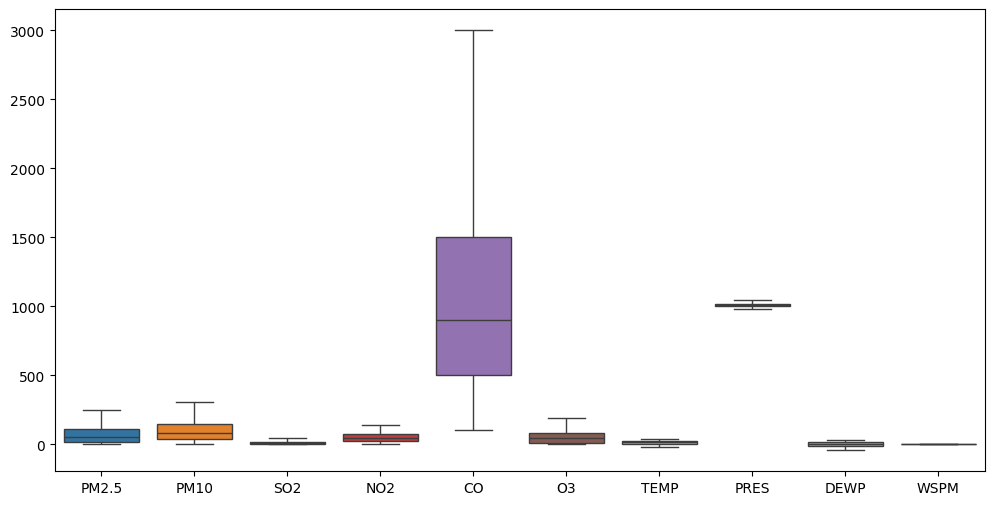

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerik])
plt.show()

**Membuat Dataframe Baru untuk Data yang Sudah Bersih**

In [18]:
df_clean = df.copy()

**Insight:**
- Missing value pada polutan (PM2.5, PM10, SO2, NO2, CO, O3) dan variabel cuaca (TEMP, PRES, DEWP, dan WSPM) ditangani menggunakan **metode interpolasi**.
- Missing value pada RAIN ditangani menggunakan **metode imputasi** dengan mengisi menggunakan nilai 0. Hal ini dilakukan untuk menghindari bias.
- Missing value pada wd ditangani menggunakan **metode imputasi** dengan mengisi menggunakan modus (nilai yang paling sering muncul). Hal ini dilakukan untuk menjaga konsistensi arah mata angin.
- Outlier ditangani menggunakan **metode IQR**.
- Data yang sudah bersih disimpan pada dataframe baru, yaitu df_clean.

## Exploratory Data Analysis (EDA)

### Explore

In [19]:
df_clean.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,76.056150,101.463990,13.529880,50.200306,1131.529229,55.590392,13.531692,1010.753337,2.482421,0.064416,1.668642,2015-03-01 11:30:00.000001024
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000,2015-03-01 11:30:00
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,247.500000,308.500000,45.500000,143.000000,3000.000000,190.000000,41.600000,1042.800000,29.100000,72.500000,4.150000,2017-02-28 23:00:00
std,10122.116943,1.177198,3.448707,8.800102,6.922195,68.208418,80.093069,14.049653,33.855855,818.445530,51.701952,11.437867,10.474302,13.797675,0.820626,1.062372,NaN


**1. Tren Bulanan PM2.5**

Menghitung rata-rata PM2.5 per bulan

In [20]:
df_clean['month'] = df_clean['datetime'].dt.month
monthly_polutan = df_clean.groupby('month')[['PM2.5']].mean().reset_index()
monthly_polutan

,month,PM2.5
0,1,85.595785
1,2,80.896797
2,3,90.005199
3,4,73.069522
4,5,63.155652
5,6,68.024266
6,7,71.310417
7,8,53.433011
8,9,61.028438
9,10,86.683122


Menghitung rata-rata PM2.5 per bulan untuk tiap stasiun

In [21]:
monthly_mean_pm25 = df_clean.groupby(['month', 'station'])['PM2.5'].mean().unstack()
monthly_mean_pm25

station,Aotizhongxin,Changping,Dingling,Dongsi,Guanyuan,Gucheng,Huairou,Nongzhanguan,Shunyi,Tiantan,Wanliu,Wanshouxigong
month,,,,,,,,,,,,
1,84.146539,79.179234,70.616958,89.934173,86.879032,90.924909,75.083501,90.900319,85.517574,89.616676,89.292708,95.057800
2,79.254794,76.524521,73.686025,84.593658,80.737555,83.496497,75.848427,83.933444,83.470870,81.218105,82.175578,85.822087
3,94.594467,81.392725,79.862802,94.426058,90.284005,93.856670,84.731536,94.048779,92.179267,90.446371,91.773135,92.466566
4,78.313194,69.815972,65.379965,76.994618,73.756771,76.673224,67.848611,73.693924,73.469618,71.249479,73.579340,76.059549
5,66.658468,60.217473,54.113520,69.033233,63.609308,67.247838,56.972877,64.027335,64.414987,61.427083,66.438441,63.707262
6,70.371007,58.930174,56.132860,73.935937,72.983160,71.187095,55.174468,71.603125,69.650972,72.856250,72.815278,70.650868
7,74.833165,62.329637,61.086837,80.212702,74.831653,71.005712,66.974227,71.857124,70.598320,73.991095,75.582829,72.421707
8,55.842910,46.787567,43.333636,58.500235,58.456015,54.641935,47.768280,54.961526,53.077655,56.415188,56.318112,55.093078
9,64.171111,54.906597,49.209315,66.692153,64.912917,65.359618,53.924306,63.986944,60.771528,63.389931,63.287917,61.728924


Membuat Kategori Musim untuk polutan PM2.5

In [22]:
season_category = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df_clean['Season'] = df_clean['month'].map(season_category)
season_polutan = df_clean.groupby('Season')[['PM2.5']].agg(['mean', 'median', 'std'])
season_polutan

PM2.5                  
             mean median        std
Season                             
Autumn  78.905123   55.0  71.936574
Spring  75.435566   59.0  62.765892
Summer  64.214938   51.0  51.078307
Winter  85.886939   56.0  81.775382

**2. Rush Hour tiap Polutan**

In [23]:
df_clean['hour'] = df_clean['datetime'].dt.hour
def waktu(hour):
  if (7<=hour <=9) or (17<=hour<=19):
    return 'Rush Hour'
  else:
    return 'Non Rush Hour'

df_clean['waktu'] = df_clean['hour'].apply(waktu)
rush_hour=df_clean.groupby('waktu')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean()
rush_hour

,PM2.5,PM10,SO2,NO2,CO,O3
waktu,,,,,,
Non Rush Hour,76.904690,101.475936,13.58784,50.073925,1132.740905,55.179632
Rush Hour,73.510532,101.428152,13.35600,50.579450,1127.894200,56.822671


**3. Korelasi Faktor Cuaca dengan Polutan**

In [24]:
polutan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
cuaca = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
correlation = df_clean[polutan + cuaca].corr()
correlation

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.000000,0.888628,0.507475,0.660831,0.789284,-0.164389,-0.107348,-0.001559,0.148153,-0.013969,-0.302070
PM10,0.888628,1.000000,0.502866,0.664300,0.707056,-0.127217,-0.077798,-0.035322,0.096129,-0.028336,-0.226342
SO2,0.507475,0.502866,1.000000,0.531290,0.600356,-0.185770,-0.361299,0.259181,-0.309283,-0.049448,-0.110734
NO2,0.660831,0.664300,0.531290,1.000000,0.720544,-0.504844,-0.280484,0.180031,-0.031984,-0.044450,-0.419525
CO,0.789284,0.707056,0.600356,0.720544,1.000000,-0.362721,-0.315692,0.180335,-0.023402,-0.010189,-0.355250
O3,-0.164389,-0.127217,-0.185770,-0.504844,-0.362721,1.000000,0.607358,-0.457512,0.313469,0.027089,0.344329
TEMP,-0.107348,-0.077798,-0.361299,-0.280484,-0.315692,0.607358,1.000000,-0.813312,0.820247,0.037662,0.057575
PRES,-0.001559,-0.035322,0.259181,0.180031,0.180335,-0.457512,-0.813312,1.000000,-0.750271,-0.060965,0.061374
DEWP,0.148153,0.096129,-0.309283,-0.031984,-0.023402,0.313469,0.820247,-0.750271,1.000000,0.086274,-0.287514
RAIN,-0.013969,-0.028336,-0.049448,-0.044450,-0.010189,0.027089,0.037662,-0.060965,0.086274,1.000000,0.020460


**Insight:**

**1. Tren Bulanan PM2.5**
- Stasiun dengan rata-rata **tertinggi berada di Wanshouxigong** pada bulan Desember (102,68 µg/m³). Sedangkan **terendah di Dingling** pada bulan Agustus (43,33 µg/m³).
- Rata-rata **tertinggi di Winter**, tepatnya bulan Desember. Sedangkan, rata-rata **terendah di Summer**, tepatnya bulan Agustus.

**2. Rush Hour tiap Polutan**
- Rush Hour: **07.00 - 09.00** dan **17.00 - 19.00**.
- Perbedaan angka antara Rush Hour dan Non Rush Hour sangat tipis.
- **CO** merupakan polutan dengan konsentrasi tertinggi di kedua waktu.
- Konsentrasi **PM2.5, PM10, SO2, dan CO lebih tinggi di Non Rush Hour**.
- Konsentrasi **NO2 dan O3 naik saat Rush Hour** (50,58 dan 56,82 µg/m³ ).

**3. Korelasi Faktor Cuaca dengan Polutan**
- WSPM memiliki **korelasi negatif** dengan PM2.5, PM10, NO2, dan CO.
- TEMP memiliki **korelasi positif** yang kuat dengan O3 (0,61), namun memiliki **korelasi negatif** dengan SO2 (-0,36).


## Visualization & Explanatory Analysis

### **1. Tren Bulanan PM2.5**
*"Bagaimana tren bulanan polutan PM2.5 di setiap stasiun?"*

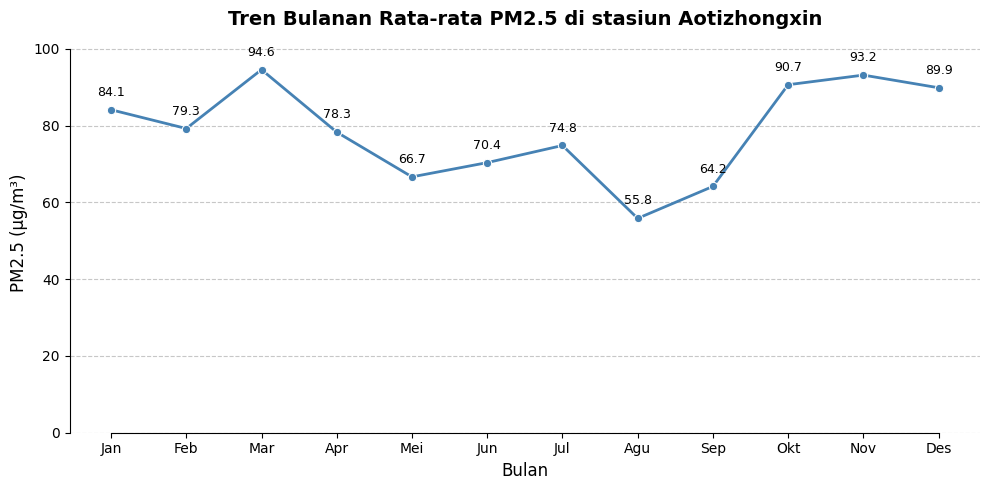

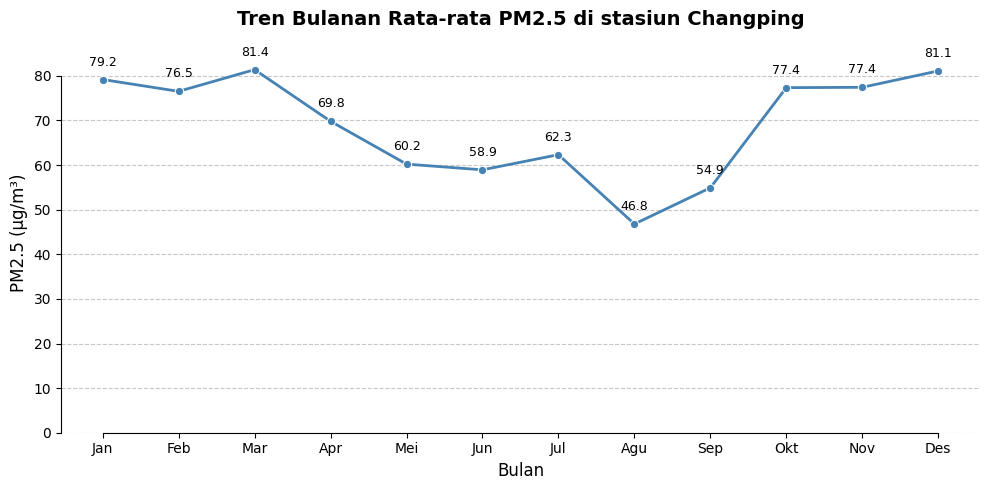

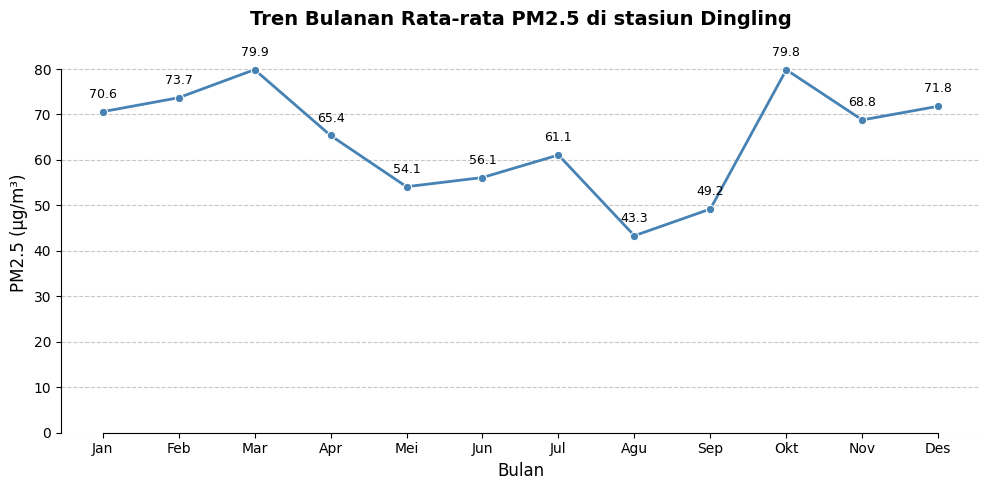

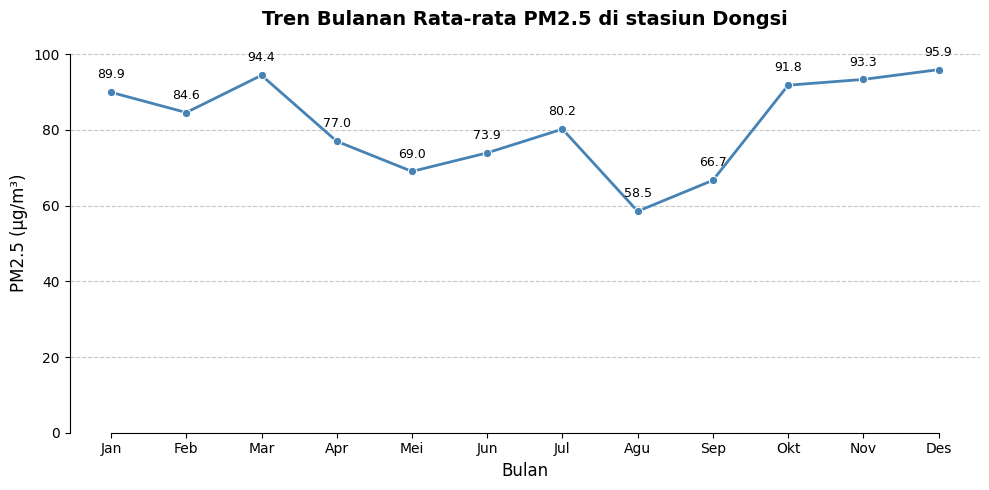

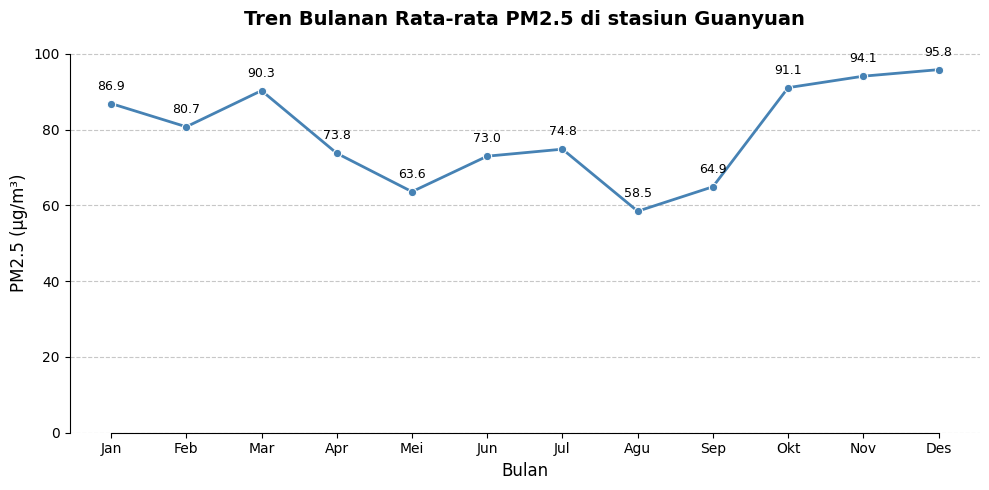

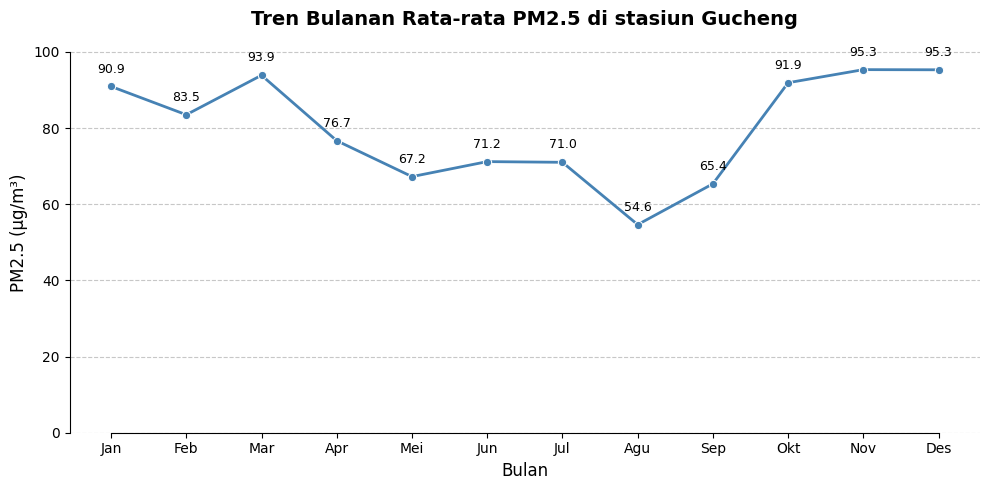

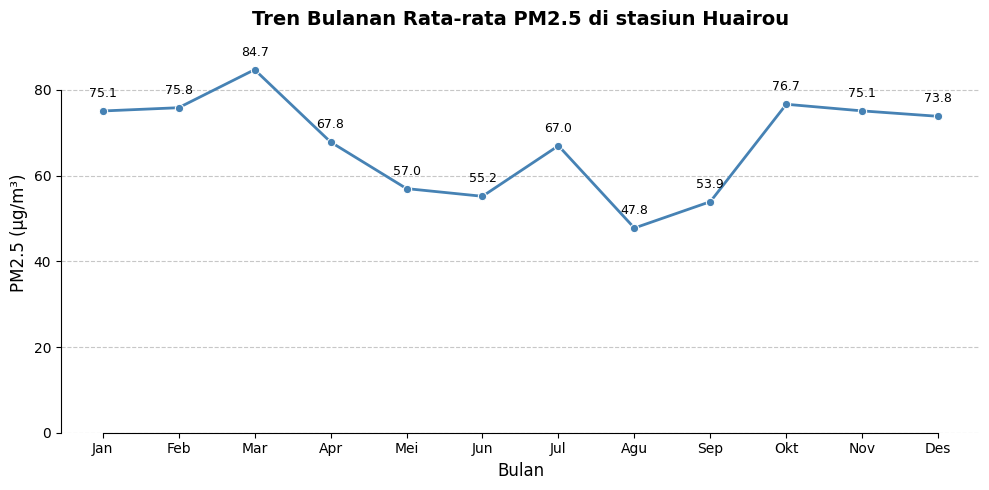

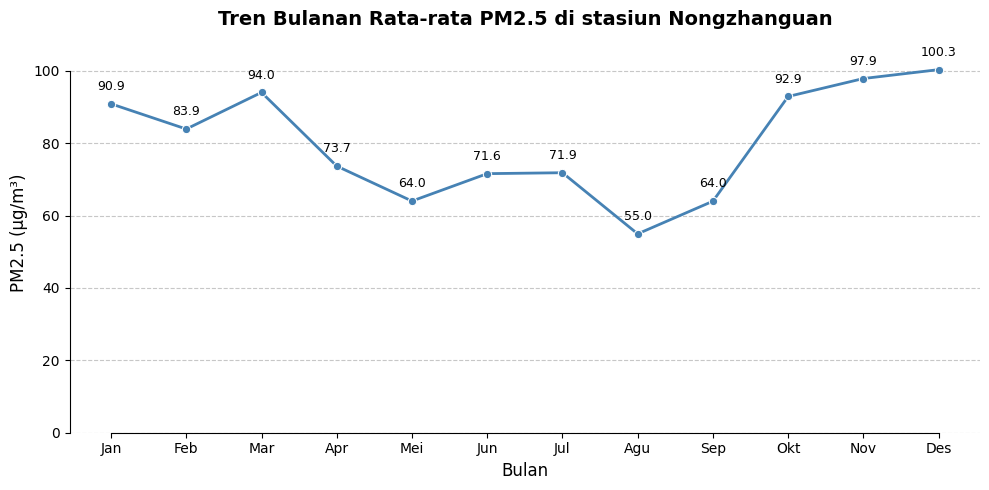

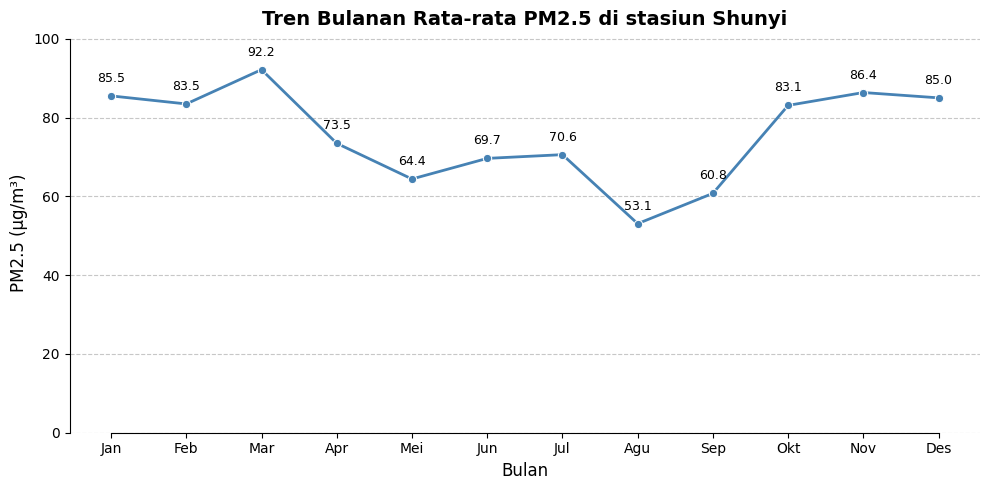

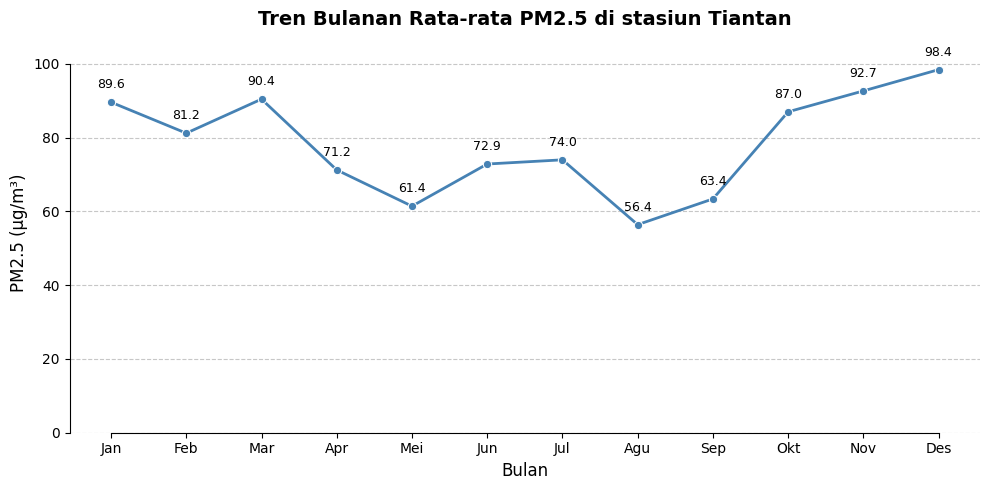

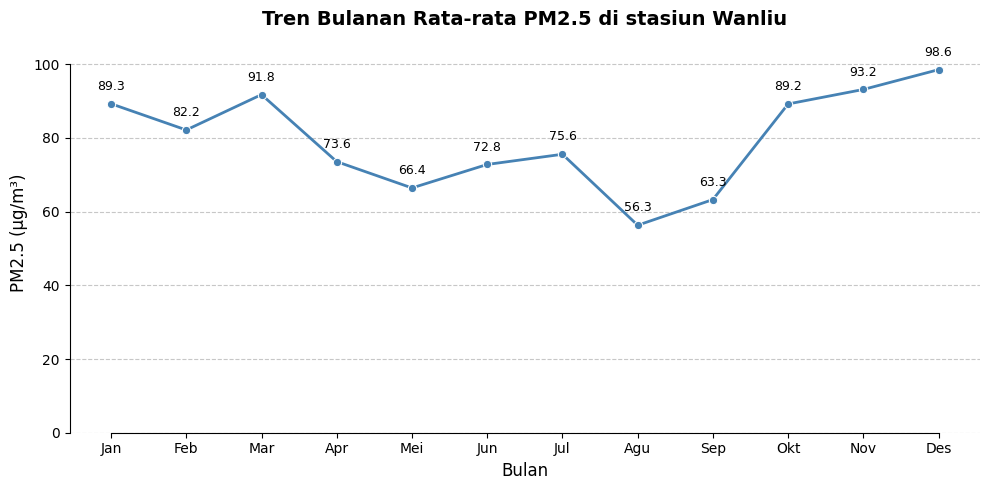

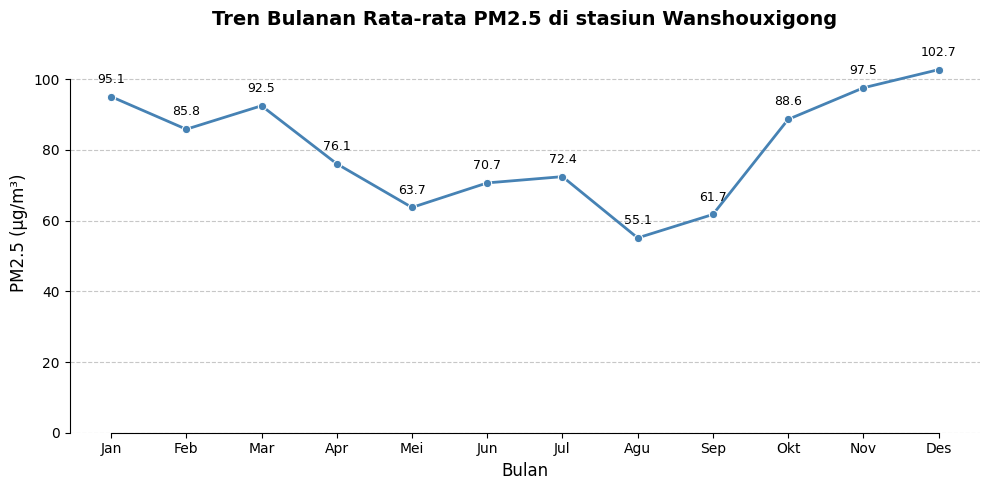

In [25]:
label_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
stasiun = ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
monthly_mean_pm25 = df_clean.groupby(['month', 'station'])['PM2.5'].mean().reset_index()

for nama_stasiun in stasiun:
    data_stasiun = monthly_mean_pm25[monthly_mean_pm25['station'] == nama_stasiun]

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=data_stasiun, x='month', y='PM2.5', marker='o', color='steelblue', linewidth=2)

    plt.title(f'Tren Bulanan Rata-rata PM2.5 di stasiun {nama_stasiun}', fontsize=14, weight='bold')
    plt.xlabel('Bulan', fontsize=12)
    plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
    plt.xticks(ticks=range(1, 13), labels=label_bulan)

    # y-axis mulai dari nol
    max_pm25 = data_stasiun['PM2.5'].max()
    if not pd.isna(max_pm25):
        plt.ylim(0, max_pm25 * 1.1)

    # Menampilkan nilai PM2.5 di atas titik
    for idx, row in data_stasiun.iterrows():
        if not pd.isna(row['PM2.5']):
            plt.text(row['month'], row['PM2.5'] + (max_pm25 * 0.03),
                     f"{row['PM2.5']:.1f}", ha='center', va='bottom', fontsize=9, color='black')

    # Menghilangkan grid yang terlalu dominan
    sns.despine(trim=True)
    plt.grid(visible=True, which='major', axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

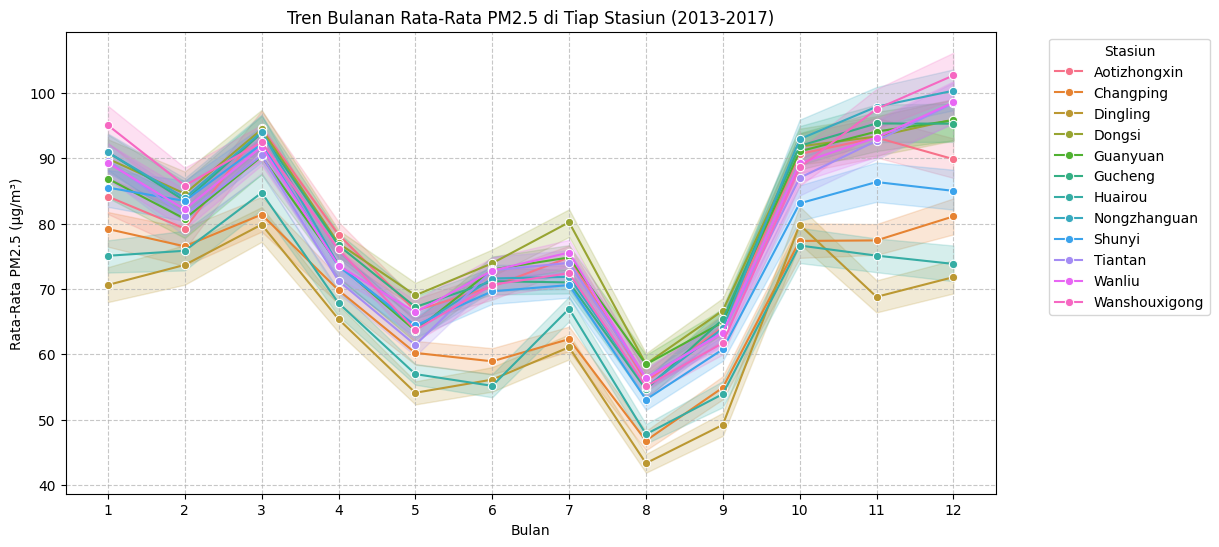

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='month', y='PM2.5', hue='station', marker='o')

plt.title('Tren Bulanan Rata-Rata PM2.5 di Tiap Stasiun (2013-2017)')
plt.xlabel('Bulan')
plt.ylabel('Rata-Rata PM2.5 (µg/m³)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Stasiun')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, 13))
plt.show()

### **2. Rush Hour tiap Polutan**
*"Polutan udara mana yang memiliki konsentrasi tertinggi saat rush hour?"*

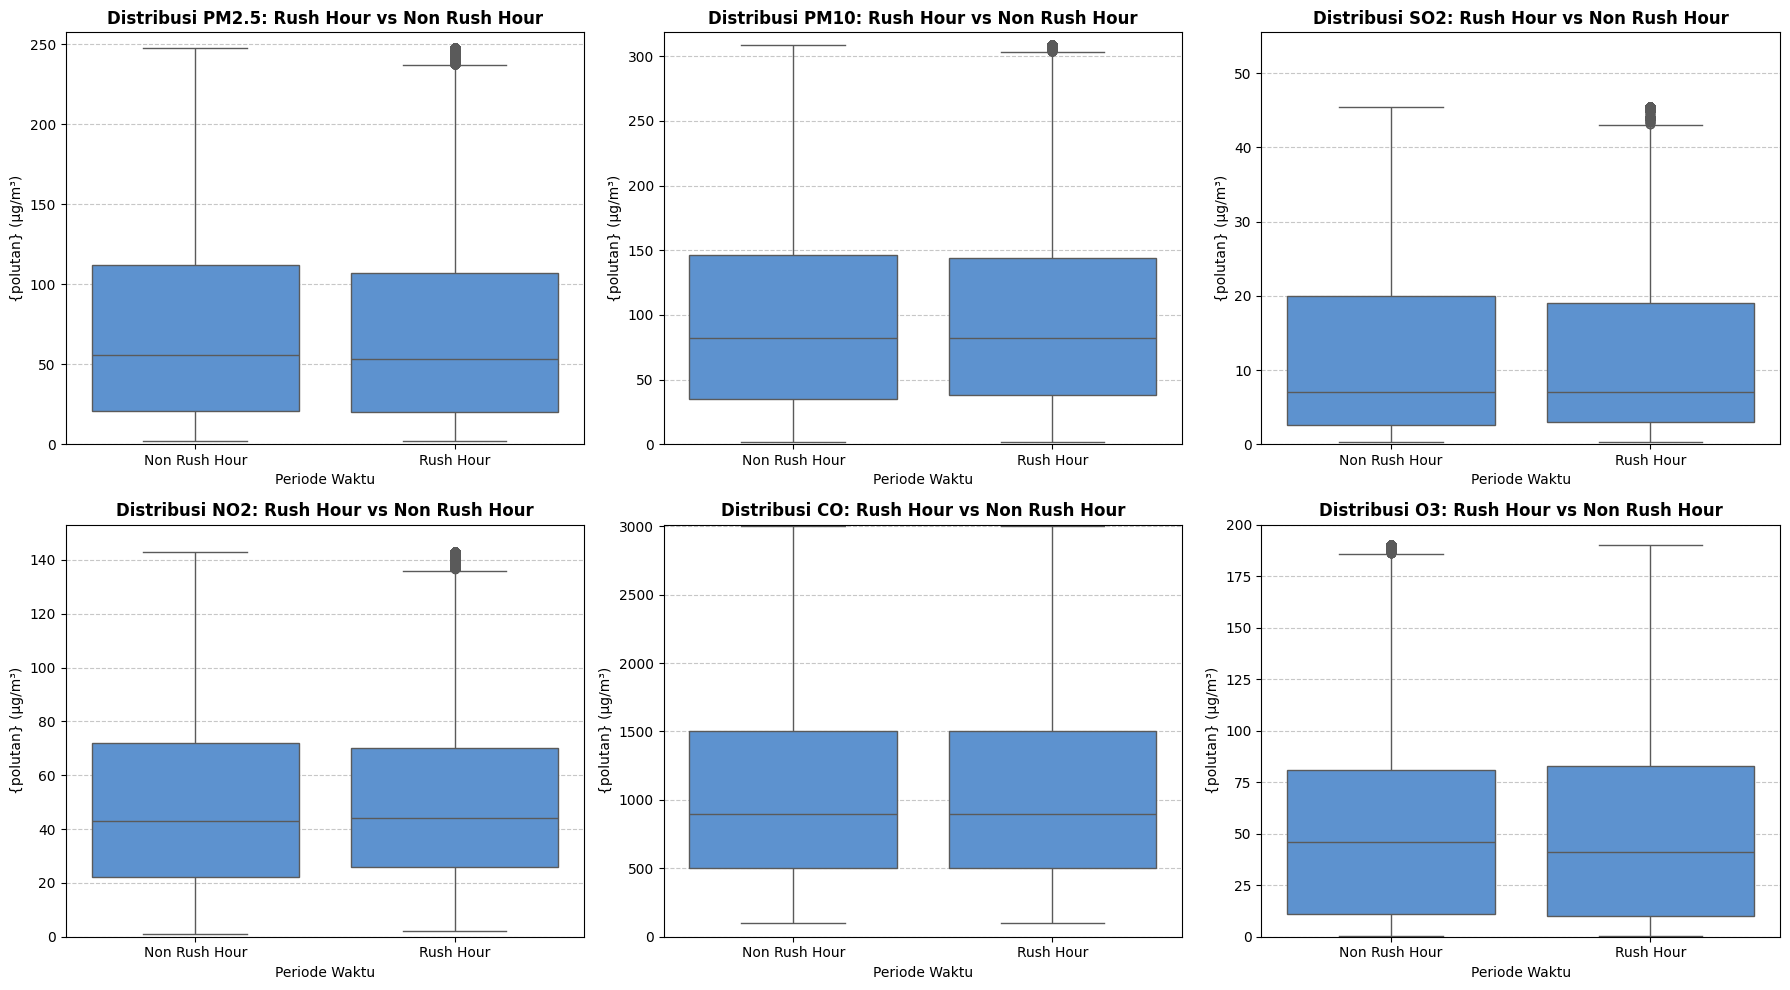

In [27]:
plt.figure(figsize=(18, 10))
polutan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

for i, polutan in enumerate(polutan):
    plt.subplot(2, 3, i + 1) # Create a 2x3 grid of subplots
    sns.boxplot(
        data=df_clean,
        x='waktu', y=polutan,
        hue='waktu',
        palette=['#4A90E2', '#4A90E2'],
        legend=False
    )
    plt.title(f'Distribusi {polutan}: Rush Hour vs Non Rush Hour', fontsize=12, weight='bold')
    plt.xlabel('Periode Waktu', fontsize=10)
    plt.ylabel('{polutan} (µg/m³)', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, df_clean[polutan].max() + 10)

plt.tight_layout()
plt.show()

### **3. Korelasi Faktor Cuaca dengan Polutan**
*"Faktor cuaca apa yang paling berpengaruh terhadap masing-masing polutan udara?"*

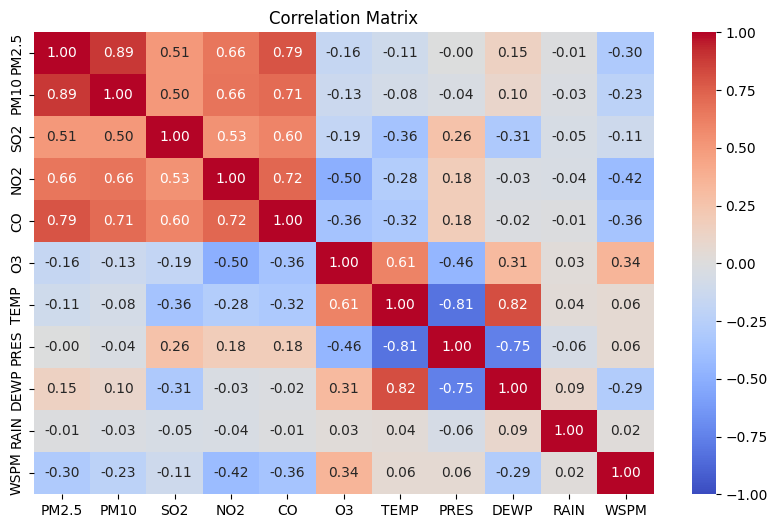

In [28]:
polutan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
cuaca = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Membuat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()

**Insight:**

**1. Tren Bulanan PM2.5**
- Seluruh stasiun menunjukkan pola musiman yang **konsisten**.
  - **Puncak**: Desember, dengan lonjakan tertinggi pada stasiun Wanshouxigong (102,7 µg/m³) dan Nongzhanguan (100,3 µg/m³).
    - Kualitas udara buruk.
  - **Rendah**: Agustus, dengan lonjakan terendah pada stasiun Dingling (43,3 µg/m³) dan Changping (46,8 µg/m³).
    - Kualitas udara baik.
  - Kualitas udara  dipengaruhi oleh **musim dan aktivitas manusia**.
- Fluktuasi tajam antar bulan.
  - **Turun** : Agustus (Aotizhongxin, Changping, Dingling, Dongsi, Huairou, Wanliu, dan Wanshouxigong) dan April (Guanyuan, Gucheng, Nongzhanguan, Shunyi, dan Tiantan).
  - **Naik** : Oktober.

**2. Rush Hour tiap Polutan**
- Perbedaan angka antara Rush Hour dan Non Rush Hour sangat tipis, artinya kualitas udara **buruk secara merata** sepanjang hari.
- **CO** merupakan polutan dengan konsentrasi tertinggi di kedua waktu.
- Konsentrasi **PM2.5, PM10, SO2, dan CO lebih tinggi di Non Rush Hour**.
- Konsentrasi **NO2 dan O3 naik saat Rush Hour** (50,57 dan 56,82 µg/m³ ).

**3. Korelasi Faktor Cuaca dengan Polutan**
- **PM2.5, PM10, NO2, CO - WSPM** (-0,30; -0,23; -0,36; -0,42).
  - Semakin kencang angin, semakin rendah konsentrasi PM2.5, PM10, NO2, dan CO.
- **SO2, O3 - TEMP**  (-0,36; 0,61 ).
  - Semakin tinggi temperatur, semakin rendah konsentrasi SO2.
  - Semakin tinggi temperatur, semakin tinggi pula konsentrasi O3.


In [37]:
# Menyimpan dataframe yang sudah dibersihkan ke format csv
df_clean.to_csv("data_clean.csv", index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Analisis Lanjutan Geospatial Analysis

**Persiapan Data**

In [30]:
df_map = df_clean.copy()

station_locations = pd.DataFrame({
    'station': ['Aotizhongxin', 'Changping', 'Dingling',
                'Dongsi', 'Guanyuan','Gucheng',
                'Huairou', 'Nongzhanguan', 'Shunyi',
                'Tiantan', 'Wanliu', 'Wanshouxigong'],
    'latitude': [39.9826, 40.2181, 40.2904,
                 39.9289, 39.9295, 39.9145,
                 40.3749, 39.9375, 40.1270,
                 39.8731, 39.9996, 39.8949],
    'longitude': [116.3970, 116.2317, 116.2302,
                  116.4177, 116.3393, 116.1853,
                  116.6371, 116.4708, 116.6545,
                  116.4123, 116.2785, 116.3466]})

df_map = df_map.merge(station_locations, on='station', how='left')

In [31]:
konsentrasi = {
    "PM2.5": [
        (0, 35, 0, 50),
        (35, 75, 51, 100),
        (75, 115, 101, 150),
        (115, 150, 151, 200),
        (150, 250, 201, 300),
        (250, 500, 301, 500)],

    "PM10": [
        (0, 50, 0, 50),
        (50, 150, 51, 100),
        (150, 250, 101, 150),
        (250, 350, 151, 200),
        (350, 420, 201, 300),
        (420, 600, 301, 500)],

    "SO2": [
        (0, 150, 0, 50),
        (150, 500, 51, 100),
        (500, 650, 101, 150),
        (650, 800, 151, 200),
        (800, 1600, 201, 300),
        (1600, 2100, 301, 500)],

    "NO2": [
        (0, 40, 0, 50),
        (40, 80, 51, 100),
        (80, 180, 101, 150),
        (180, 280, 151, 200),
        (280, 565, 201, 300),
        (565, 940, 301, 500)],

    "CO": [
        (0, 2000, 0, 50),
        (2000, 4000, 51, 100),
        (4000, 14000, 101, 150),
        (14000, 24000, 151, 200),
        (24000, 36000, 201, 300),
        (36000, 60000, 301, 500)],

    "O3": [
        (0, 100, 0, 50),
        (100, 160, 51, 100),
        (160, 215, 101, 150),
        (215, 265, 151, 200),
        (265, 800, 201, 300),
        (800, 1000, 301, 500)]}

**Perhitungan IAQI**

In [32]:
def hitung_iaqi(conc, konsentrasi_list):
  for low, high, i_low, i_high in konsentrasi_list:
    if low <= conc <= high:
      return ((i_high - i_low)/(high - low)) * (conc-low) + i_low
  return None

for pol in konsentrasi.keys():
  df_map[f'IAQI_{pol}'] = df_clean[pol].apply(lambda x: hitung_iaqi(x,konsentrasi[pol]))

**Penentuan AQI Dominan**

In [33]:
aqi_col = [f'IAQI_{p}' for p in konsentrasi.keys()]
df_map['AQI'] = df_map[aqi_col].max(axis=1)
df_map['AQI_Dominant'] = df_map[aqi_col].idxmax(axis=1)
df_map['AQI_Dominant'].value_counts()

,count
AQI_Dominant,
IAQI_PM2.5,206020
IAQI_NO2,85730
IAQI_O3,75806
IAQI_PM10,51198
IAQI_CO,2014


**Penentuan AQI**

In [34]:
aqi_final = df_map.groupby('station', as_index=False).agg(
    AQI=('AQI', 'mean'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first')
)

**Mapping untuk Visualisasi Peta**

In [35]:
def kategori_warna(aqi):
  if aqi <= 50: return 'Baik', 'Green'
  elif aqi <= 100: return 'Sedang', 'Yellow'
  elif aqi <= 150: return 'Tidak Sehat bagi Kelompok Sensitif', 'Orange'
  elif aqi <= 200: return 'Tidak Sehat', 'Red'
  elif aqi <= 300: return 'Sangat Tidak Sehat', 'Purple'
  else: return 'Berbahaya', 'Maroon'

aqi_final['kategori'], aqi_final['warna']=zip(*aqi_final['AQI'].apply(kategori_warna))
aqi_final

,station,AQI,latitude,longitude,kategori,warna
0,Aotizhongxin,119.212154,39.9826,116.3970,Tidak Sehat bagi Kelompok Sensitif,Orange
1,Changping,104.827353,40.2181,116.2317,Tidak Sehat bagi Kelompok Sensitif,Orange
2,Dingling,98.451659,40.2904,116.2302,Sedang,Yellow
3,Dongsi,120.564966,39.9289,116.4177,Tidak Sehat bagi Kelompok Sensitif,Orange
4,Guanyuan,118.849845,39.9295,116.3393,Tidak Sehat bagi Kelompok Sensitif,Orange
5,Gucheng,119.871243,39.9145,116.1853,Tidak Sehat bagi Kelompok Sensitif,Orange
6,Huairou,100.681517,40.3749,116.6371,Tidak Sehat bagi Kelompok Sensitif,Orange
7,Nongzhanguan,120.654099,39.9375,116.4708,Tidak Sehat bagi Kelompok Sensitif,Orange
8,Shunyi,111.575553,40.1270,116.6545,Tidak Sehat bagi Kelompok Sensitif,Orange
9,Tiantan,118.247538,39.8731,116.4123,Tidak Sehat bagi Kelompok Sensitif,Orange


**Visulisasi Peta**

In [36]:
map = folium.Map(location=[aqi_final.latitude.mean(), aqi_final.longitude.mean()], zoom_start=12, control_scale=True)

for index, station_info in aqi_final.iterrows():
    folium.CircleMarker(
        location=[station_info['latitude'], station_info['longitude']],
        radius=8,
        color=station_info['warna'],
        fill=True,
        fill_color=station_info['warna'],
        fill_opacity=0.7,
        popup=f"{station_info['station']}\n {station_info['kategori']}\nAQI: {station_info['AQI']:.1f}"
    ).add_to(map)

map

**Insight**

Menampilkan peta sebaran kualitas udara (AQI) di 12 stasiun pemantauan Beijing menggunakan indikator warna berdasarkan standar AQI Beijing:
- 🟢Hijau : Baik (0 - 50)
- 🟡Kuning : Sedang (51 - 100)
- 🟠Oranye : Tidak Sehat bagi Kelompok Sensitif (101 - 150)
- 🔴Merah : Tidak Sehat (151 - 200)
- 🟣Ungu : Sangat Tidak Sehat (201 - 300)
- 🟤Maroon : Berbahaya (300+)

1. Kualitas udara didominasi kategori **"Tidak Sehat bagi Kelompok Sensitif"**
    - **11 stasiun**, dengan AQI tertinggi berada di **Wanliu** (AQI: 121,47), Nongzhanguan (AQI: 120,65), dan Dongsi (AQI: 120,56).
    - Menunjukan kualitas udara di area tersebut **buruk bagi orang dengan penyakit pernapasan**.
    - Berada di **area padat** dengan kemungkinan lalu lintas atau aktivitas industri yang tinggi.

2. Kualitas udara kategori **"Sedang"**
    - **Dingling** (AQI: 98,45).
    - Menunjukan kualitas udara di area ini masih dalam **batas aman**, namun polutan tertentu dapat berdampak bagi beberapa orang.
    - Berada di **area pinggiran** yang lebih hijau dan jauh dari keramaian.



## Conclusion

**1. Bagaimana tren bulanan polutan PM2.5 di setiap stasiun?**

Kualitas udara di seluruh stasiun menunjukkan pola musiman yang konsisten, di mana konsentrasi PM2.5 mencapai puncaknya pada musim dingin (Desember) dan berada di titik terendah pada musim panas (Agustus). Lonjakan di bulan Desember kemungkinan besar dipicu oleh peningkatan aktivitas pemanas ruangan dan kondisi atmosfer yang stabil. Wanshouxigong menjadi stasiun dengan risiko tertinggi (102,68 µg/m³), sedangkan Dingling relatif lebih bersih.  Hal ini terjadi karena Wanshouxigong terletak di pusat kota dengan aktivitas manusia yang tinggi, sedangkan Dingling terletak jauh di utara pusat kota.

**2. Polutan udara mana yang memiliki konsentrasi tertinggi saat rush hour?**

Karbon Monoksida (CO) mendominasi sebagai polutan dengan konsentrasi tertinggi pada rush hour. Meskipun terdapat kenaikan pada NO2 dan O3 selama rush hour, perbedaan angka yang sangat tipis dengan waktu lainnya menunjukkan bahwa polusi udara di sudah berada pada level buruk secara merata sepanjang hari.

**3. Faktor cuaca apa yang paling berpengaruh terhadap masing-masing polutan udara?**

Kecepatan Angin (WSPM) yang kencang berperan sebagai pembersih alami yang menurunkan kadar mayoritas polutan (PM2.5, PM10, NO2, dan CO) karena adanya korelasi negatif. Sedangkan, temperatur (TEMP) menurunkan konsentrasi SO2 tetapi menaikkan konsentrasi O3. Hal ini menunjukkan bahwa suhu tinggi dapat memicu reaksi kimia antara polutan yang menghasilkan ozon. Oleh karena itu, panasnya hari tidak selalu identik dengan udara bersih, melainkan bisa menjadi hari di mana kualitas udara yang berbahaya bagi kesehatan karena tingginya ozon.